Assignement 2 - Fitting and Alignment<br>Q1 Section (a) - Total least square line fitting

Line parameters in form: ax + by + c=0
a: 0.7735616496467872
b: -0.6337210539312553
c: -3.794192210845812

Line parameters in form: y = mx + d
m: 1.2206658510839083
d: -5.9871645218487535


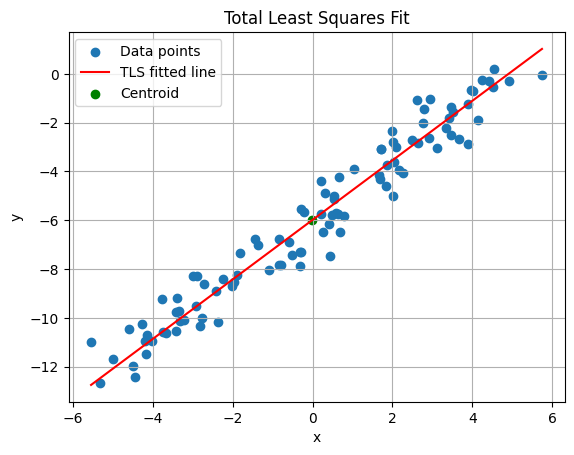

In [44]:
import numpy as np
import matplotlib.pyplot as plt

D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

x = D[:,0]
y = D[:,3]

points = np.column_stack((x,y))

centroid = points.mean(axis=0)
points_centered = points - centroid

U, S, Vt = np.linalg.svd(points_centered)
normal = Vt[-1]
a, b = normal
c = -normal @ centroid

print("Line parameters in form: ax + by + c=0")
print("a:", a)
print("b:", b)
print("c:", c)

# Convert to solpe form for plotting
if abs(b) > 1e-6:
    m = -a / b
    d = -c / b

    x_line = np.linspace(min(x), max(x), 100)
    y_line = m * x_line + d
else:
    # Vertical line case
    x_line = np.full(100, -c / a)
    y_line = np.linspace(min(y), max(y), 100)

print("\nLine parameters in form: y = mx + d")
print("m:", m)
print("d:", d)

# plot
plt.scatter(x, y, label="Data points")
plt.plot(x_line, y_line, 'r', label="TLS fitted line")
plt.scatter(*centroid, color='green', label="Centroid")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Total Least Squares Fit")
plt.grid()

plt.show()

Section (b) - Find lines using RANSAC


Detected Lines (ax + by + c = 0):

Line 1:
  a = -0.7293819223574926
  b = 0.6841067251080701
  c = -0.6397482836608148

Line 2:
  a = -0.3913204869036268
  b = -0.9202544629228964
  c = 2.0419731514889117

Line 3:
  a = -0.8306850157159579
  b = 0.5567426736518217
  c = 3.7060136914190966



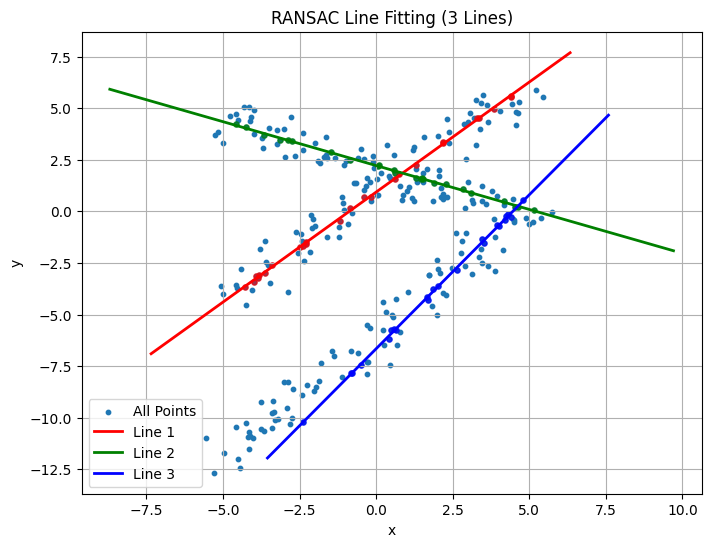

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###################
# Helper functions
###################
def points_to_line(p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    a = y1 - y2
    b = x2 - x1
    c = x1*y2 - x2*y1

    return a, b, c

def point_line_distance(points, a, b, c):
    return np.abs(a*points[:, 0] + b*points[:, 1] + c) / np.sqrt(a*a + b*b)

def fit_line_using_svd(points):
    centroid = points.mean(axis=0)
    centered = points - centroid
    _, _, Vt = np.linalg.svd(centered)
    normal = Vt[-1]
    a, b = normal
    c = -normal @ centroid
    return a, b, c

def ransac(points, n_iter=2000, threshold=0.1):
    best_inliers = []
    best_model = None

    points_lenght = len(points)

    for _ in range(n_iter):
        # Randomly select 2 distinct points
        idx = np.random.choice(points_lenght, 2, replace=False)
        p1, p2 = points[idx]

        if np.allclose(p1, p2):
            continue

        a, b, c = points_to_line(p1, p2)

        dists = point_line_distance(points, a, b, c)
        inlier_mask = dists < threshold
        inliers = points[inlier_mask]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)

    # Refine using TLS
    a, b, c = fit_line_using_svd(best_inliers)

    return (a, b, c), best_inliers

###########################
# Load data and run RANSAC
###########################
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

X_cols = D[:, :3]
Y_cols = D[:, 3:]

points = np.column_stack((X_cols.flatten(), Y_cols.flatten()))

# Find 3 lines using RANSAC
remaining = points.copy()
lines = []
all_inliers = []

for i in range(3):
    model, inliers = ransac(remaining, n_iter=1500, threshold=0.1)

    lines.append(model)
    all_inliers.append(inliers)

    # Remove inliers
    dists = point_line_distance(remaining, *model)
    remaining = remaining[dists >= 0.1]


# Report parameters
print("\nDetected Lines (ax + by + c = 0):\n")

for i, (a, b, c) in enumerate(lines):
    print(f"Line {i+1}:")
    print(f"  a = {a}")
    print(f"  b = {b}")
    print(f"  c = {c}\n")

###############
# Plot results
###############
plt.figure(figsize=(8, 6))

# Plot all points
plt.scatter(points[:, 0], points[:, 1], s=10, label="All Points")

colors = ['r', 'g', 'b']

for i, (a, b, c) in enumerate(lines):
    direction = np.array([b, -a])
    centroid = all_inliers[i].mean(axis=0)
    t = np.linspace(-10, 10, 100)
    line_pts = centroid + t[:, None] * direction
    plt.plot(line_pts[:, 0], line_pts[:, 1], colors[i], linewidth=2, label=f"Line {i+1}")
    plt.scatter(all_inliers[i][:, 0], all_inliers[i][:, 1], 
                s=15, color=colors[i], alpha=0.6)

plt.xlabel("x")
plt.ylabel("y")
plt.title("RANSAC Line Fitting; 3 Lines")
plt.legend()
plt.grid()

plt.show()